# Companion Notebook — Redes Neurais Artificiais

**Disciplina:** GCC1734 — Inteligência Artificial  
**Tema:** Aprendizado de Máquina — Seção 6: Redes Neurais Artificiais  
**Objetivo:** transformar os conceitos das notas de aula em experimentos curtos em Python.

Este notebook acompanha a seção **Redes Neurais Artificiais** das notas. Ele cobre:

1. o perceptron como classificador linear;
2. a conexão entre um neurônio com sigmoide e regressão logística;
3. por que a não linearidade é essencial;
4. funções de ativação;
5. propagação direta (*forward pass*) em um MLP;
6. retropropagação (*backpropagation*) em uma rede pequena;
7. treinamento por gradiente descendente estocástico;
8. uso prático de `MLPClassifier` do `scikit-learn`;
9. diagnóstico de underfitting/overfitting em redes neurais.

> **Observação didática.** As primeiras células usam `NumPy` para expor os cálculos. Depois usamos `scikit-learn` para aproximar o fluxo de trabalho usual de aprendizado supervisionado.

## 0. Preparação do ambiente

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import expit  # sigmoid numericamente estável

from sklearn.datasets import make_moons, make_classification
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [29]:
def plot_2d_dataset(X, y, title=None):
    '''Plota um conjunto de dados 2D com rótulos binários.'''
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=40)
    if title:
        plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()


def plot_decision_boundary(model, X, y, title=None, grid_step=0.02):
    '''Plota a fronteira de decisão de um classificador 2D.'''
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=40)
    if title:
        plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()

## 1. Um único neurônio: combinação linear + ativação

Nas notas, o perceptron recebe um vetor de entrada $x$, calcula

$$
z = w^\top x + b
$$

e aplica uma função de ativação $\sigma$ para produzir a saída.

Com ativação degrau, ele funciona como um classificador linear. Com ativação sigmoide, sua saída pode ser interpretada como uma probabilidade, exatamente como na regressão logística.

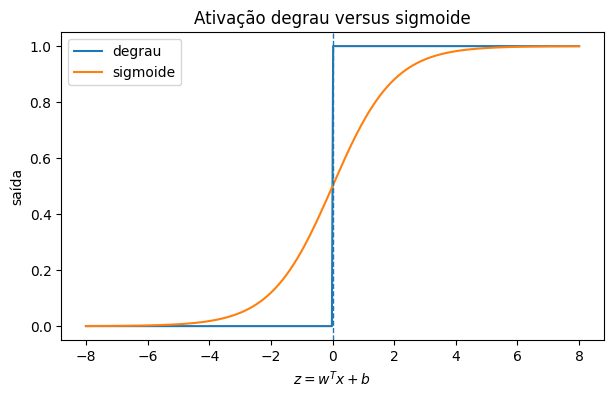

In [30]:
def step_activation(z):
    return (z >= 0).astype(int)


def sigmoid(z):
    return expit(z)


z = np.linspace(-8, 8, 400)

plt.figure(figsize=(7, 4))
plt.plot(z, step_activation(z), label="degrau")
plt.plot(z, sigmoid(z), label="sigmoide")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("$z = w^T x + b$")
plt.ylabel("saída")
plt.title("Ativação degrau versus sigmoide")
plt.legend()
plt.show()

### Exemplo: classificador linear em dados separáveis

Vamos gerar um problema 2D aproximadamente linearmente separável e comparar:

- `Perceptron`: usa uma regra de atualização inspirada no perceptron clássico;
- `LogisticRegression`: usa sigmoide e otimiza entropia cruzada.

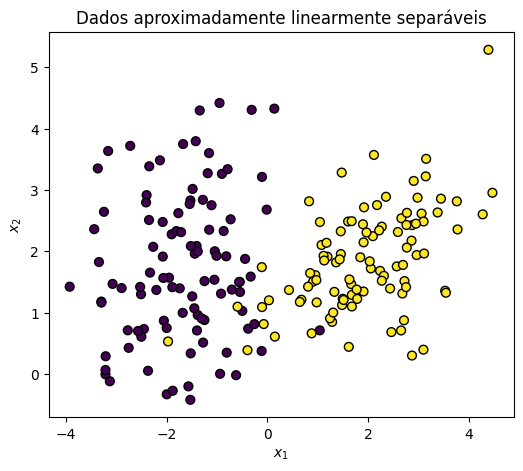

In [31]:
X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    random_state=RANDOM_STATE
)

plot_2d_dataset(X_linear, y_linear, "Dados aproximadamente linearmente separáveis")

In [32]:
perceptron_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", Perceptron(max_iter=1000, eta0=0.1, random_state=RANDOM_STATE))
])

logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])

perceptron_model.fit(X_linear, y_linear)
logreg_model.fit(X_linear, y_linear)

print("Acurácia do Perceptron:", accuracy_score(y_linear, perceptron_model.predict(X_linear)))
print("Acurácia da Regressão Logística:", accuracy_score(y_linear, logreg_model.predict(X_linear)))

Acurácia do Perceptron: 0.965
Acurácia da Regressão Logística: 0.965


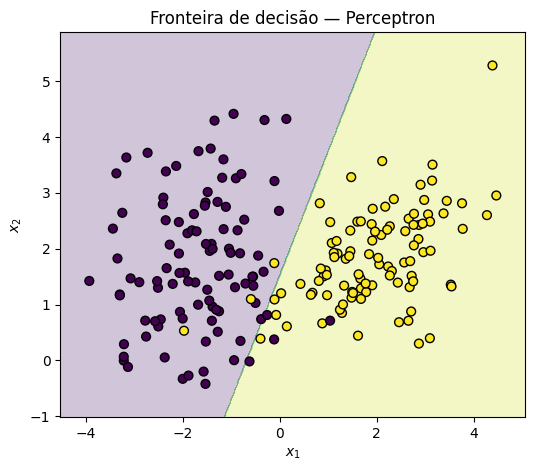

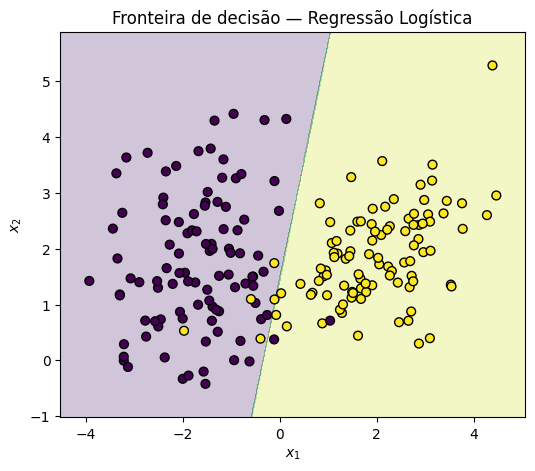

In [33]:
plot_decision_boundary(perceptron_model, X_linear, y_linear, "Fronteira de decisão — Perceptron")
plot_decision_boundary(logreg_model, X_linear, y_linear, "Fronteira de decisão — Regressão Logística")

## 2. Limitação do perceptron: problemas não linearmente separáveis

Um único neurônio com ativação degrau ou sigmoide continua sendo um modelo linear em relação às entradas originais. Portanto, ele não consegue resolver bem problemas como XOR, círculos concêntricos ou luas intercaladas.

A seguir, usamos um conjunto do tipo `make_moons`, que não é linearmente separável.

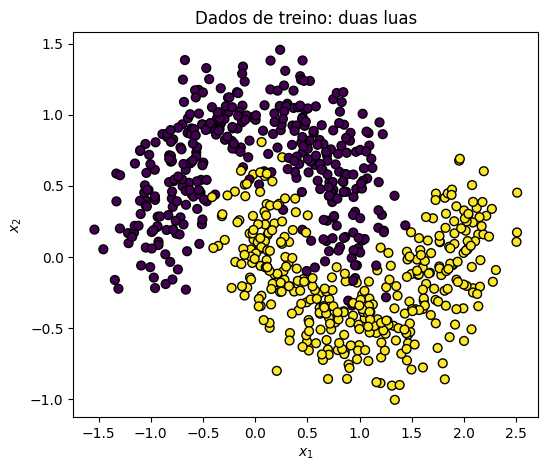

In [34]:
X_moons, y_moons = make_moons(
    n_samples=1050,
    noise=0.22,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.30,
    stratify=y_moons,
    random_state=RANDOM_STATE
)

plot_2d_dataset(X_train, y_train, "Dados de treino: duas luas")

Acurácia treino: 0.8680272108843538
Acurácia teste: 0.8857142857142857


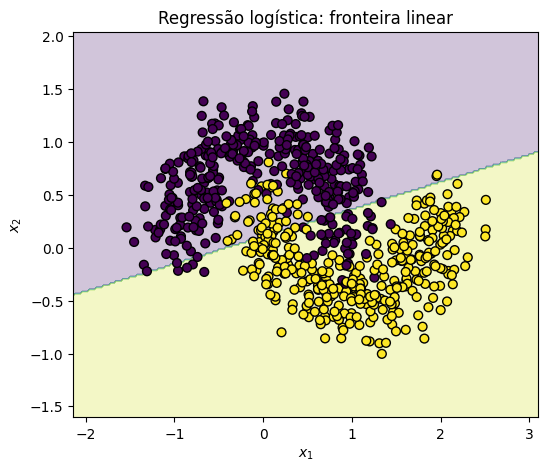

In [35]:
linear_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])

linear_clf.fit(X_train, y_train)

print("Acurácia treino:", accuracy_score(y_train, linear_clf.predict(X_train)))
print("Acurácia teste:", accuracy_score(y_test, linear_clf.predict(X_test)))

plot_decision_boundary(linear_clf, X_train, y_train, "Regressão logística: fronteira linear")

## 3. Funções de ativação

Sem função de ativação não linear, empilhar camadas lineares não aumenta a expressividade: a composição de transformações lineares continua sendo linear.

Abaixo comparamos três ativações comuns:

- sigmoide;
- tangente hiperbólica;
- ReLU.

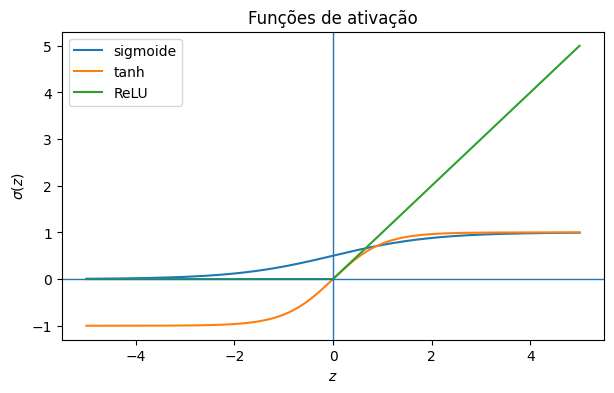

In [37]:
def tanh(z):
    return np.tanh(z)


def relu(z):
    return np.maximum(0, z)


z = np.linspace(-5, 5, 400)

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid(z), label="sigmoide")
plt.plot(z, tanh(z), label="tanh")
plt.plot(z, relu(z), label="ReLU")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("$z$")
plt.ylabel("$\\sigma(z)$")
plt.title("Funções de ativação")
plt.legend()
plt.show()

### Derivadas das ativações

A retropropagação precisa das derivadas das ativações. Quando a derivada fica muito pequena em muitos pontos, o gradiente pode praticamente desaparecer. Esse é um dos motivos pelos quais sigmoide e tanh podem ser problemáticas em redes profundas.

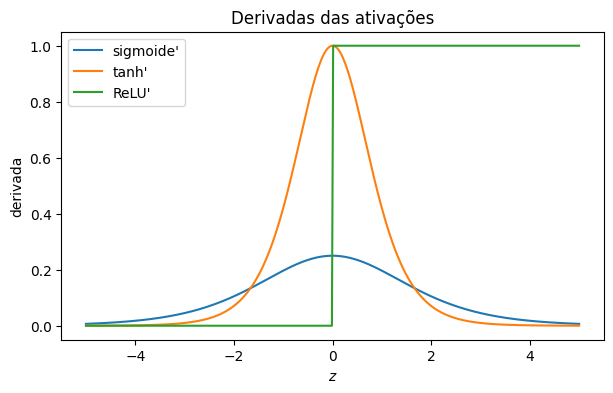

In [38]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2


def relu_derivative(z):
    return (z > 0).astype(float)


plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid_derivative(z), label="sigmoide'")
plt.plot(z, tanh_derivative(z), label="tanh'")
plt.plot(z, relu_derivative(z), label="ReLU'")
plt.xlabel("$z$")
plt.ylabel("derivada")
plt.title("Derivadas das ativações")
plt.legend()
plt.show()

## 4. Propagação direta em um MLP pequeno

Vamos construir manualmente uma rede com:

- 2 entradas;
- 3 neurônios ocultos;
- 1 saída sigmoide para classificação binária.

A rede calcula:

$$
h = \tanh(XW_1 + b_1)
$$

$$
\hat{y} = \sigma(hW_2 + b_2)
$$

In [39]:
# Pequeno lote com 4 exemplos e 2 características
X_batch = np.array([
    [0.2, 0.1],
    [0.4, 0.7],
    [0.8, 0.3],
    [0.9, 0.8],
])

# Rótulos binários
y_batch = np.array([[0], [0], [1], [1]])

# Inicialização dos parâmetros
rng = np.random.default_rng(RANDOM_STATE)

W1 = rng.normal(scale=0.5, size=(2, 3))
b1 = np.zeros((1, 3))

W2 = rng.normal(scale=0.5, size=(3, 1))
b2 = np.zeros((1, 1))

print("X_batch:", X_batch.shape)
print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

X_batch: (4, 2)
W1: (2, 3)
b1: (1, 3)
W2: (3, 1)
b2: (1, 1)


In [40]:
def forward_pass(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    H = np.tanh(Z1)
    Z2 = H @ W2 + b2
    y_hat = sigmoid(Z2)
    cache = {
        "X": X,
        "Z1": Z1,
        "H": H,
        "Z2": Z2,
        "y_hat": y_hat
    }
    return y_hat, cache


y_hat, cache = forward_pass(X_batch, W1, b1, W2, b2)

print("Previsões probabilísticas:")
print(np.round(y_hat, 4))

Previsões probabilísticas:
[[0.5091]
 [0.5346]
 [0.528 ]
 [0.5414]]


## 5. Entropia cruzada binária

Para classificação binária com saída sigmoide, a perda usual é a entropia cruzada binária:

$$
J = -\frac{1}{n}\sum_{i=1}^n
\left[
y^{(i)}\log(\hat{y}^{(i)})
+
(1-y^{(i)})\log(1-\hat{y}^{(i)})
\right].
$$

In [41]:
def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


loss = binary_cross_entropy(y_batch, y_hat)
print("Perda inicial:", loss)

Perda inicial: 0.6822050747504527


## 6. Retropropagação em uma rede pequena

A retropropagação aplica a regra da cadeia para calcular os gradientes da perda em relação a todos os parâmetros.

Para a combinação **sigmoide + entropia cruzada binária**, o gradiente na saída simplifica para:

$$
\frac{\partial J}{\partial Z_2} = \frac{\hat{y} - y}{n}.
$$

Depois propagamos esse erro para trás:

$$
\frac{\partial J}{\partial W_2} = H^\top \frac{\partial J}{\partial Z_2}
$$

$$
\frac{\partial J}{\partial W_1} =
X^\top \left[
\left(\frac{\partial J}{\partial Z_2} W_2^\top\right)
\odot (1-\tanh^2(Z_1))
\right].
$$

In [42]:
def backward_pass(y_true, W2, cache):
    X = cache["X"]
    Z1 = cache["Z1"]
    H = cache["H"]
    y_hat = cache["y_hat"]

    n = X.shape[0]

    dZ2 = (y_hat - y_true) / n
    dW2 = H.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dH = dZ2 @ W2.T
    dZ1 = dH * (1 - np.tanh(Z1) ** 2)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }
    return gradients


grads = backward_pass(y_batch, W2, cache)

for name, value in grads.items():
    print(name, value.shape)
    print(np.round(value, 5))

dW1 (2, 3)
[[-0.0062   0.00593  0.001  ]
 [-0.0007  -0.00164  0.00022]]
db1 (1, 3)
[[ 0.00271 -0.01294 -0.00018]]
dW2 (3, 1)
[[-0.02502]
 [ 0.04873]
 [-0.02992]]
db2 (1, 1)
[[0.02826]]


### Um passo de gradiente descendente

Agora aplicamos a atualização:

$$
\theta \leftarrow \theta - \alpha \nabla_\theta J.
$$

In [43]:
learning_rate = 0.5

W1_new = W1 - learning_rate * grads["dW1"]
b1_new = b1 - learning_rate * grads["db1"]
W2_new = W2 - learning_rate * grads["dW2"]
b2_new = b2 - learning_rate * grads["db2"]

y_hat_new, _ = forward_pass(X_batch, W1_new, b1_new, W2_new, b2_new)
loss_new = binary_cross_entropy(y_batch, y_hat_new)

print("Perda antes:", loss)
print("Perda depois de um passo:", loss_new)

Perda antes: 0.6822050747504527
Perda depois de um passo: 0.679718582386452


## 7. Treinando um MLP do zero com mini-batch gradient descent

Agora juntamos tudo: inicialização, propagação direta, perda, retropropagação e atualização dos pesos.

Usaremos o conjunto `make_moons` novamente.

In [44]:
def initialize_mlp(input_dim, hidden_dim, output_dim=1, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(scale=0.5, size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))
    W2 = rng.normal(scale=0.5, size=(hidden_dim, output_dim))
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2


def train_numpy_mlp(
    X,
    y,
    hidden_dim=10,
    learning_rate=0.1,
    epochs=1000,
    batch_size=32,
    seed=42
):
    y = y.reshape(-1, 1)

    W1, b1, W2, b2 = initialize_mlp(X.shape[1], hidden_dim, seed=seed)
    rng = np.random.default_rng(seed)

    losses = []

    for epoch in range(epochs):
        indices = rng.permutation(X.shape[0])

        for start in range(0, X.shape[0], batch_size):
            batch_idx = indices[start:start + batch_size]
            X_b = X[batch_idx]
            y_b = y[batch_idx]

            y_hat_b, cache_b = forward_pass(X_b, W1, b1, W2, b2)
            grads_b = backward_pass(y_b, W2, cache_b)

            W1 -= learning_rate * grads_b["dW1"]
            b1 -= learning_rate * grads_b["db1"]
            W2 -= learning_rate * grads_b["dW2"]
            b2 -= learning_rate * grads_b["db2"]

        y_hat, _ = forward_pass(X, W1, b1, W2, b2)
        losses.append(binary_cross_entropy(y, y_hat))

    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return params, losses


def predict_numpy_mlp(X, params):
    y_hat, _ = forward_pass(X, params["W1"], params["b1"], params["W2"], params["b2"])
    return (y_hat >= 0.5).astype(int).ravel()

Acurácia treino: 0.9659863945578231
Acurácia teste: 0.9523809523809523


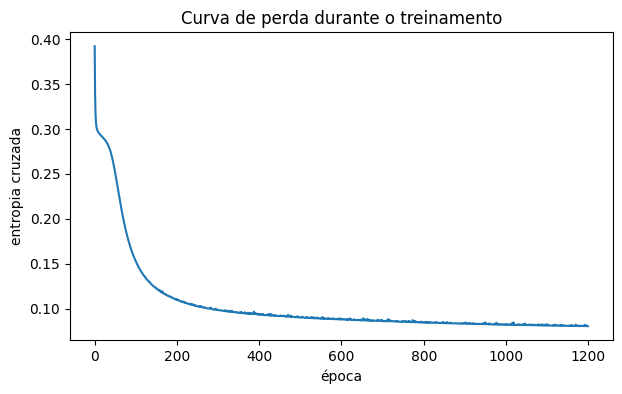

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

params, losses = train_numpy_mlp(
    X_train_scaled,
    y_train,
    hidden_dim=10,
    learning_rate=0.1,
    epochs=1200,
    batch_size=32,
    seed=RANDOM_STATE
)

y_pred_train = predict_numpy_mlp(X_train_scaled, params)
y_pred_test = predict_numpy_mlp(X_test_scaled, params)

print("Acurácia treino:", accuracy_score(y_train, y_pred_train))
print("Acurácia teste:", accuracy_score(y_test, y_pred_test))

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("época")
plt.ylabel("entropia cruzada")
plt.title("Curva de perda durante o treinamento")
plt.show()

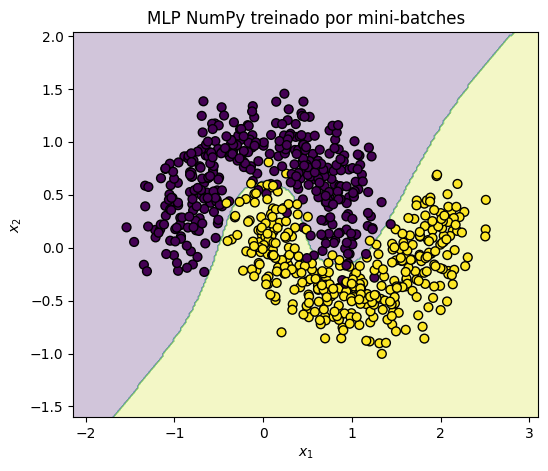

In [46]:
class NumpyMLPWrapper:
    '''Adaptador simples para usar a função plot_decision_boundary.'''
    def __init__(self, params, scaler):
        self.params = params
        self.scaler = scaler

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return predict_numpy_mlp(X_scaled, self.params)


numpy_mlp_model = NumpyMLPWrapper(params, scaler)
plot_decision_boundary(numpy_mlp_model, X_train, y_train, "MLP NumPy treinado por mini-batches")

## 8. Usando `MLPClassifier` do scikit-learn

Na prática, raramente implementamos backprop manualmente. Usamos bibliotecas que cuidam dos detalhes numéricos.

Mesmo com `scikit-learn`, os conceitos continuam os mesmos:

- `hidden_layer_sizes`: arquitetura;
- `activation`: função de ativação;
- `alpha`: regularização L2;
- `learning_rate_init`: taxa de aprendizado inicial;
- `max_iter`: número máximo de épocas/iterações.

Acurácia treino: 0.9714285714285714
Acurácia teste: 0.9492063492063492


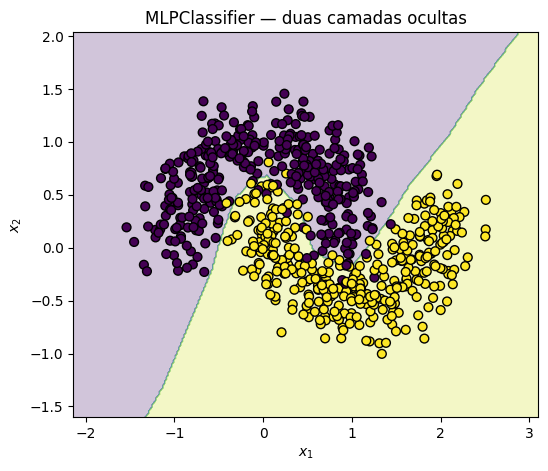

In [47]:
sk_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(20, 20),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

sk_mlp.fit(X_train, y_train)

print("Acurácia treino:", accuracy_score(y_train, sk_mlp.predict(X_train)))
print("Acurácia teste:", accuracy_score(y_test, sk_mlp.predict(X_test)))

plot_decision_boundary(sk_mlp, X_train, y_train, "MLPClassifier — duas camadas ocultas")

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       158
           1       0.95      0.95      0.95       157

    accuracy                           0.95       315
   macro avg       0.95      0.95      0.95       315
weighted avg       0.95      0.95      0.95       315



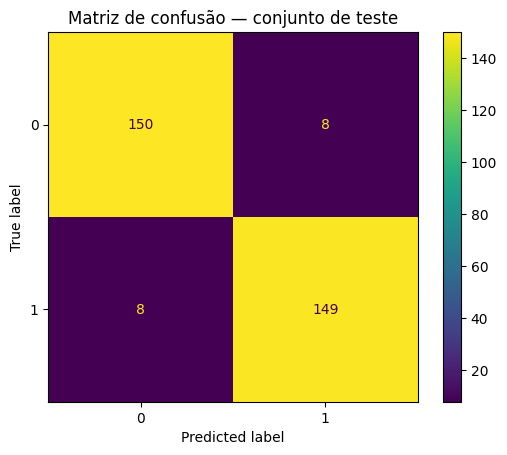

In [48]:
print(classification_report(y_test, sk_mlp.predict(X_test)))

ConfusionMatrixDisplay.from_estimator(sk_mlp, X_test, y_test)
plt.title("Matriz de confusão — conjunto de teste")
plt.show()